<a href="https://colab.research.google.com/github/deeksha216/Deep_Learning-lab/blob/main/DL4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28, 1)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9531 - loss: 0.1563
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9854 - loss: 0.0474
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9898 - loss: 0.0330
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9918 - loss: 0.0257
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9942 - loss: 0.0188
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9895 - loss: 0.0304
Test loss 0.030399518087506294
Test accuracy 0.9894999861717224
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
7


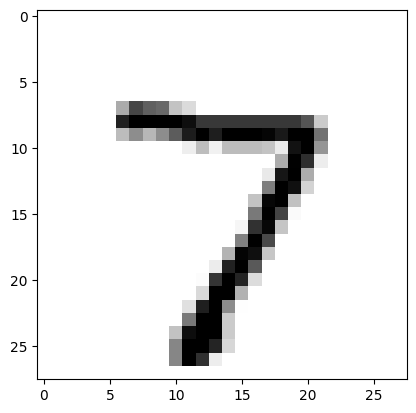

In [1]:
#CNN model
import keras

from keras.datasets import mnist
from keras.layers import Dense, Activation, Flatten, Conv2D, MaxPooling2D
from keras.models import Sequential
from keras.utils import to_categorical

import numpy as np
import matplotlib.pyplot as plt


(train_X, train_Y), (test_X, test_Y) = mnist.load_data()


train_X = train_X.reshape(-1, 28, 28, 1)
test_X = test_X.reshape(-1, 28, 28, 1)

print(train_X.shape)


train_X = train_X.astype('float32')
test_X = test_X.astype('float32')



train_X = train_X / 255
test_X = test_X / 255


train_Y_one_hot = to_categorical(train_Y)
test_Y_one_hot = to_categorical(test_Y)



model = Sequential()

model.add(Conv2D(64, (3, 3), input_shape=(28, 28, 1)))
model.add(Activation('relu'))

model.add(MaxPooling2D(pool_size=(2, 2)))


model.add(Conv2D(64, (3, 3)))
model.add(Activation('relu'))

model.add(MaxPooling2D(pool_size=(2, 2)))


model.add(Flatten())

model.add(Dense(64))
model.add(Activation('relu'))

model.add(Dense(10))
model.add(Activation('softmax'))



model.compile(
    loss=keras.losses.categorical_crossentropy,
    optimizer=keras.optimizers.Adam(),
    metrics=['accuracy']
)


model.fit(
    train_X,
    train_Y_one_hot,
    batch_size=64,
    epochs=5
)



test_loss, test_acc = model.evaluate(
    test_X,
    test_Y_one_hot
)

print('Test loss', test_loss)
print('Test accuracy', test_acc)


predictions = model.predict(test_X)



print(np.argmax(np.round(predictions[0])))



plt.imshow(
    test_X[0].reshape(28, 28),
    cmap=plt.cm.binary
)

plt.show()